In [41]:
%matplotlib inline
%config InlineBackend.figure_format ='retina'
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()

In [9]:
import numpy as np
from sklearn.decomposition import PCA
from tqdm.autonotebook import trange

slide N18 from lecture about PCA algorithm:


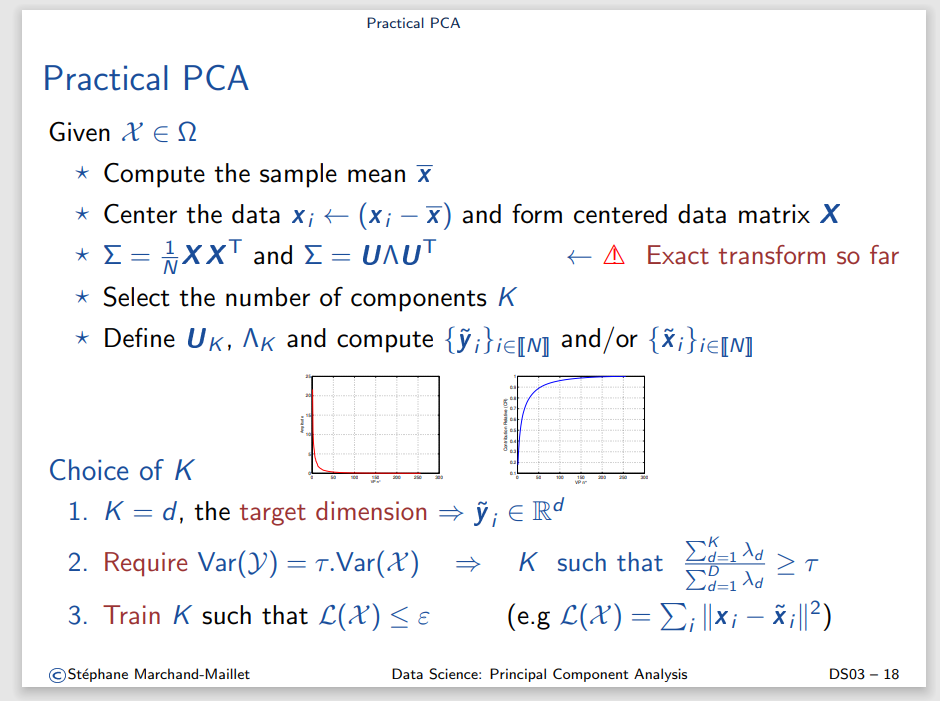

# Part 1: PCA calculation step by step

Step 1: Get your data

In [10]:
X = np.array([(2, 1), (3, 5), (4, 3), \
              (5, 6), (6, 7), (7, 8)])
X, X.shape

(array([[2, 1],
        [3, 5],
        [4, 3],
        [5, 6],
        [6, 7],
        [7, 8]]),
 (6, 2))

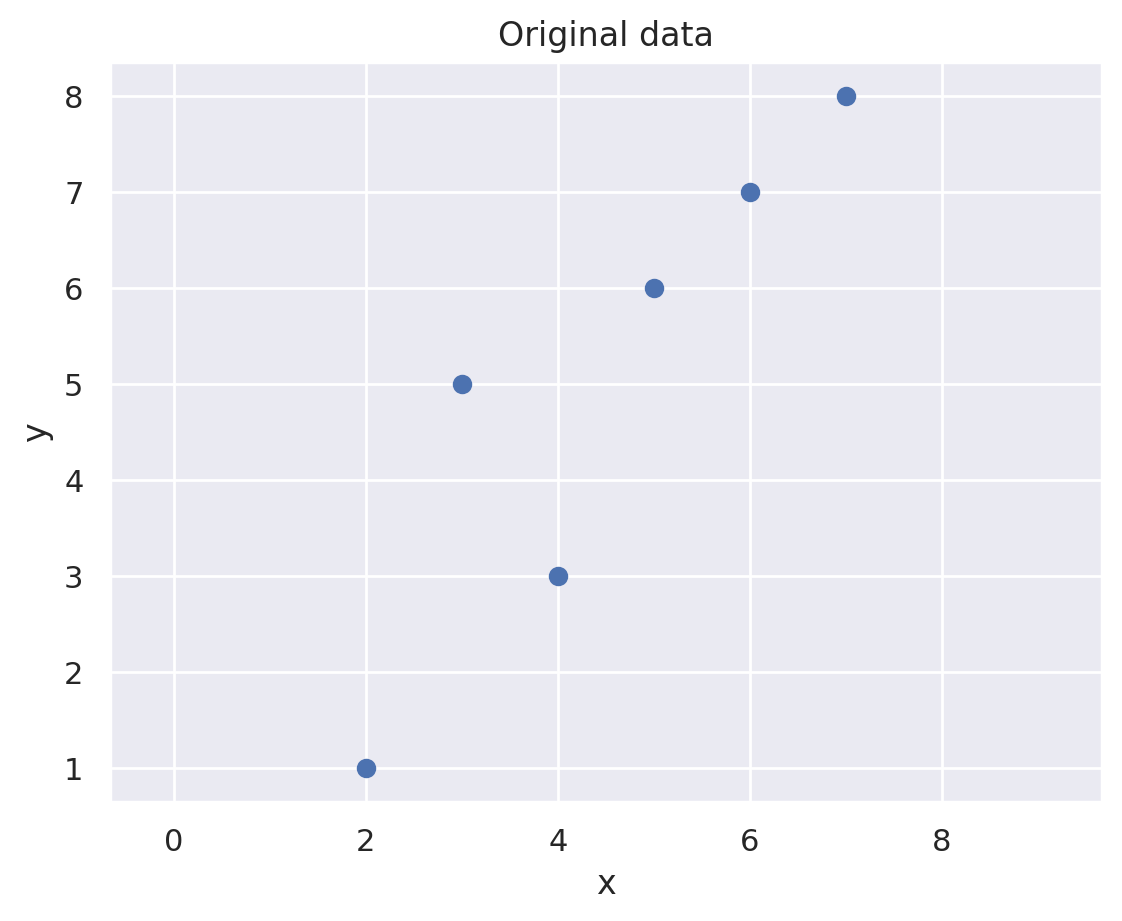

In [11]:
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original data")
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal');

Step 2: Center your data

In [12]:
mu =  np.mean(X, axis=0) # compute mean
mu

array([4.5, 5. ])

In [13]:
assert mu[1] == (1 + 5 + 3 + 6 + 7 + 8) / 6

In [14]:
A = X - mu# substract mean from data
A

array([[-2.5, -4. ],
       [-1.5,  0. ],
       [-0.5, -2. ],
       [ 0.5,  1. ],
       [ 1.5,  2. ],
       [ 2.5,  3. ]])

In [15]:
np.mean(A, axis=0)

array([0., 0.])

In [16]:
assert np.allclose(np.mean(A, axis=0), 0)

Step 3: Get Covariance of A

In [19]:
cov = 1 / (A.shape[0] - 1) * (A.T @ A)# compute covariance
print(np.cov(A.T))
cov

[[3.5 4.4]
 [4.4 6.8]]


array([[3.5, 4.4],
       [4.4, 6.8]])

In [20]:
assert cov.shape == (2, 2), 'covariance of two features should by 2x2 matrix'
assert np.all(np.linalg.eigvals(cov) >= 0) and np.array_equal(cov, cov.T), 'covariance should b positive semidefinite matrix'

Step 4: Calculate Eigen Vectors and Eigen Values

In [21]:
values, vectors = np.linalg.eig(cov)# find values and vectors

In [22]:
values

array([0.45079794, 9.84920206])

The second one should be much more important.

Step 5: Sort values and vectors descending

In [23]:
indices = np.argsort(values)[::-1]
values = values[indices]
vectors = vectors[:, indices]
values, vectors = values, vectors# sort by importance

Plot Explained Variance

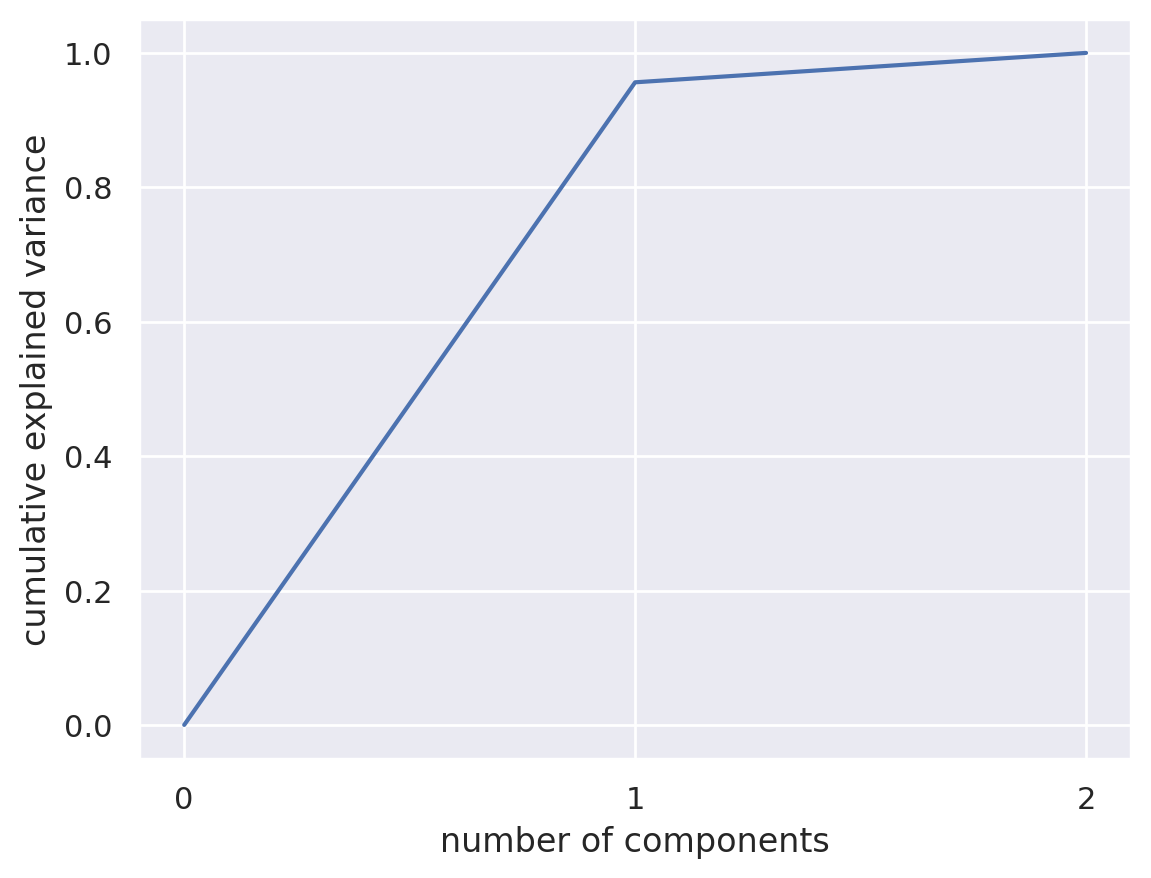

In [24]:
plt.plot(np.concatenate([[0], np.cumsum(values / values.sum())]))
plt.gca().xaxis.get_major_locator().set_params(integer=True)
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

Step 6: Calculate the transformation using all vectors initially

In [25]:
P = A @ vectors
P

array([[ 4.71168956, -0.22356531],
       [ 0.85439226,  1.23288843],
       [ 1.92864865, -0.72822687],
       [-1.10672304,  0.15863203],
       [-2.49824349, -0.09369875],
       [-3.88976395, -0.34602953]])

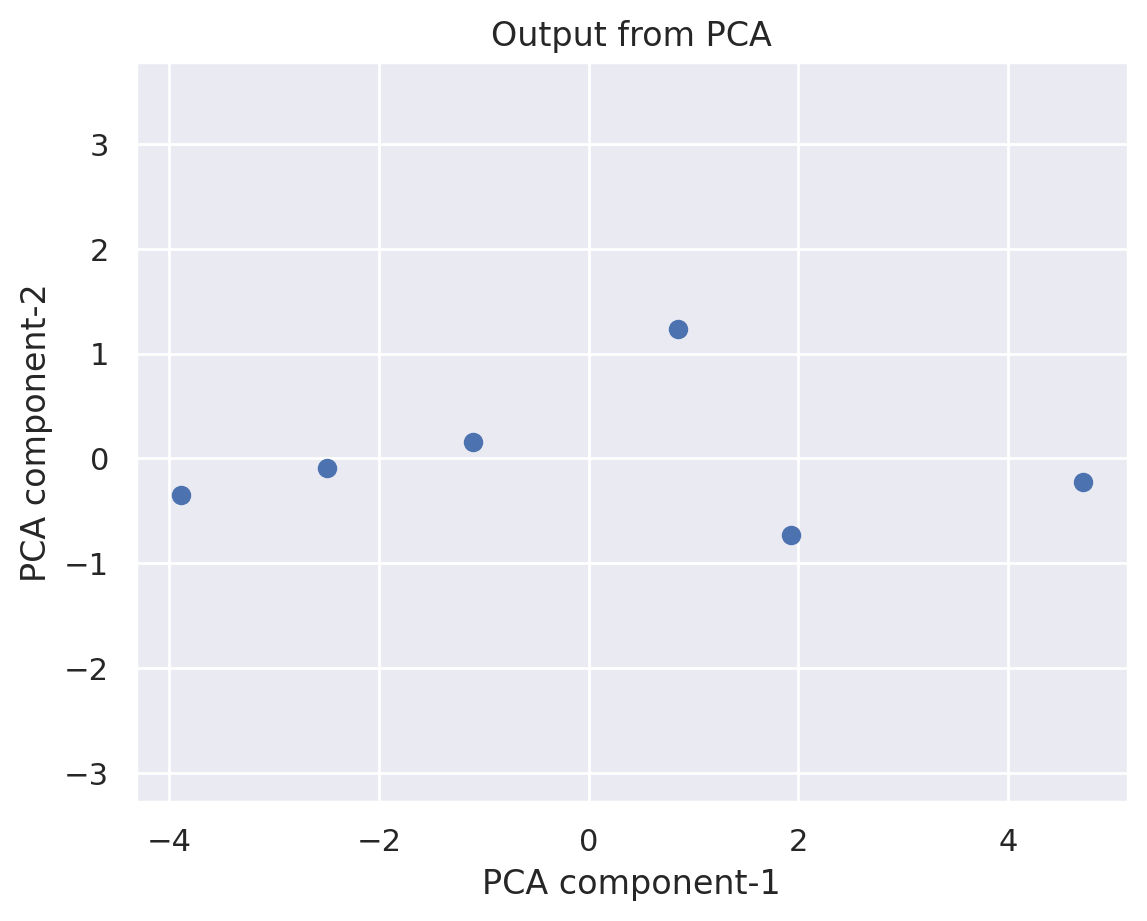

In [26]:
plt.scatter(P[:, 0], P[:, 1])
plt.title("Output from PCA")
plt.xlabel('PCA component-1')
plt.ylabel('PCA component-2')
plt.axis('equal');

Step 7: select only from the biggest eigen value

In [27]:
component_1 = P[:, 0].reshape(-1, 1)

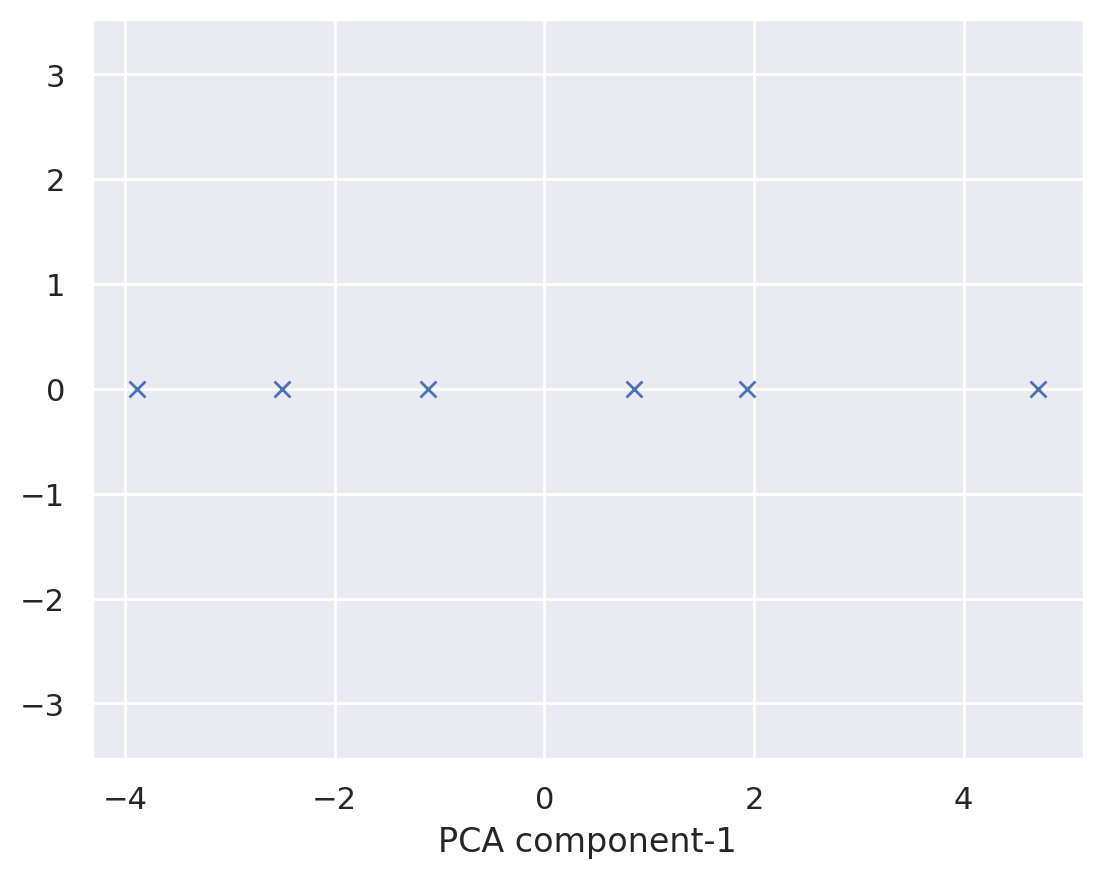

In [28]:
plt.plot(component_1, np.zeros_like(component_1), 'x')
plt.xlabel('PCA component-1')
plt.axis('equal');

Step 8: select only from the smallest eigen value (for debug only)

In [29]:
component_2 = P[:, 1].reshape(-1, 1)

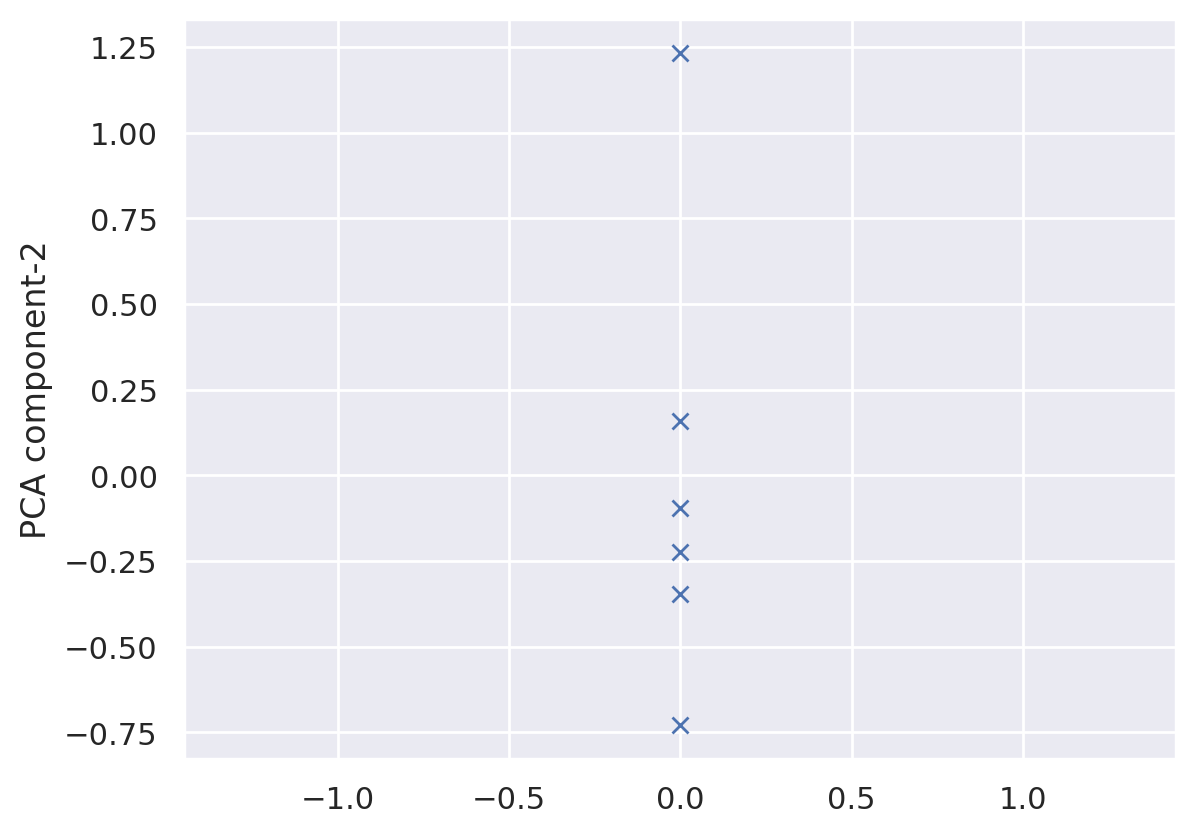

In [30]:
plt.plot(np.zeros_like(component_2), component_2, 'x')
plt.ylabel('PCA component-2')
plt.axis('equal');

### Compare with sklearn

In [31]:
from sklearn.decomposition import PCA
pca = PCA(n_components=1, svd_solver='full')

In [32]:
pca.fit(X)

,n_components,1
,copy,True
,whiten,False
,svd_solver,'full'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [33]:
pca.mean_

array([4.5, 5. ])

In [34]:
pca.get_covariance()

array([[3.5, 4.4],
       [4.4, 6.8]])

In [35]:
pca.transform(X)

array([[-4.71168956],
       [-0.85439226],
       [-1.92864865],
       [ 1.10672304],
       [ 2.49824349],
       [ 3.88976395]])

In [36]:
assert np.allclose(pca.mean_, mu)
assert np.allclose(pca.get_covariance(), cov)
# sklearn can flip the axis, so it will be negative
# but we are not interested in the direction, only transformation
assert np.allclose(abs(pca.transform(X) / component_1), 1)

They are the same!

### Conclusion of the first part

To compute PCA you need to do the following:
* Compute the mean for every dimension of the whole dataset.
* Compute the covariance matrix of the whole dataset.
* Compute eigenvectors and the corresponding eigenvalues.
* Sort the eigenvectors by decreasing eigenvalues and choose k eigenvectors with the largest eigenvalues to form a d × k dimensional matrix W.
* Use this d × k eigenvector matrix to transform the samples onto the new subspace.

[nice explanation](https://sebastianraschka.com/Articles/2015_pca_in_3_steps.html)

[source](https://towardsdatascience.com/the-mathematics-behind-principal-component-analysis-fff2d7f4b643)

Steps from [here](https://iq.opengenus.org/algorithm-principal-component-analysis-pca/)

Or you can just use `sklearn` library (much cleaner, faster, ...)

# Part 2: PCA calculation via single class

You've successfully implemented PCA calculation step-by-step. Congratulations!

Now you need to combine your solution in a single class, based on `sklearn` interface. To know more about the interface refer to the [documentation](https://scikit-learn.org/stable/developers/develop.html#rolling-your-own-estimator).

In this section you need to implement `__init__`, `fit`, `transform` and `inverse_transform` methods.

Then you need to launch the next cell to test correctness of your class.

In [37]:
from sklearn.base import TransformerMixin, BaseEstimator

In [93]:
class CustomPCA(TransformerMixin, BaseEstimator):
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean = None
        self.values = None
        self.vectors = None
        self.X = None

    def fit(self, X):
        """
        Fit the model with X.
        """
        self.mean = np.mean(X)
        self.X = X
        return self

    def transform(self, X):
        """
        Apply dimensionality reduction to X.
        """
        self.mean = np.mean(X)
        X_centered = X - self.mean
        cov = np.cov(X_centered.T)
        # self.vectors, self.values, _ = np.linalg.svd(cov, hermitian=True)
        self.values, self.vectors = np.linalg.eig(cov)
        indices = np.argsort(self.values)[::-1]
        self.values = self.values[indices[:self.n_components]]
        self.vectors = self.vectors[:, indices[:self.n_components]]
        return - X_centered @ self.vectors

    def inverse_transform(self, X):
        """
        Transform data back to its original space.
        """
        return X @ self.vectors + self.mean

In [94]:
### some utility code ###

SAMPLES_MIN, SAMPLES_MAX = 5, 10000
FEATURES_MIN, FEATURES_MAX = 2, 300
def generate_random_matrix(rng, n_samples=None, n_features=None):
    if n_samples is None:
        n_samples = rng.randint(SAMPLES_MIN, SAMPLES_MAX + 1)
    if n_features is None:
        n_features = rng.randint(FEATURES_MIN, FEATURES_MAX + 1)
    random_type = rng.randint(2)
    if random_type == 0:
        # uniform distribution
        low, high = rng.rand(2) * 100
        low, high = min(low, high), max(low, high)
        return rng.uniform(low, high, (n_samples, n_features)).astype(np.float64)
    # normal distribution
    loc, scale = rng.rand(2) * 100
    return rng.normal(loc, scale, (n_samples, n_features)).astype(np.float64)


def check_pca(X, custom_pca, sklearn_pca, matrix_name=''):
    custom_transform = custom_pca.transform(X)
    sklearn_transform = sklearn_pca.transform(X)
    print(custom_transform[:, 0])
    print(sklearn_transform[:, 0])
    assert np.all(np.isclose(custom_transform - sklearn_transform, 0) | np.isclose(custom_transform + sklearn_transform, 0)), f'pca transform does not equal with sklearn for {matrix_name} matrix'

    custom_inverse_transform = custom_pca.inverse_transform(custom_transform)
    sklearn_inverse_transform = sklearn_pca.inverse_transform(sklearn_transform)

    assert np.allclose(custom_inverse_transform, sklearn_inverse_transform), f'pca inverse transform does not equal with sklearn for {matrix_name} matrix'

In [95]:
%%time
rng = np.random.RandomState(42)
N_RETRIES = 20
N_DIFFERENT_COMPONENTS = 2
N_DIFFERENT_MATRICIES = 2

for _ in trange(N_RETRIES):
    X = generate_random_matrix(rng)
    n_samples, n_features = X.shape

    for n_components in rng.choice(range(1, n_features + 1), min(N_DIFFERENT_COMPONENTS, n_features), replace=False):
        custom_pca = CustomPCA(n_components=n_components).fit(X)
        sklearn_pca = PCA(n_components=n_components, svd_solver='full').fit(X)

        check_pca(X, custom_pca, sklearn_pca, 'original')

        for _ in range(N_DIFFERENT_MATRICIES):
            Y = generate_random_matrix(rng, n_features=n_features)
            check_pca(Y, custom_pca, sklearn_pca, 'different')

  0%|          | 0/20 [00:03<?, ?it/s]

[-6.0490406  -0.56053329  0.77898556 ... 14.41166829  7.28348811
 14.36370734]
[-6.04247583 -0.55396853  0.78555033 ... 14.41823306  7.29005288
 14.37027211]
CPU times: user 3.55 s, sys: 6.67 ms, total: 3.56 s
Wall time: 3.57 s


AssertionError: pca transform does not equal with sklearn for original matrix

# Part 3 (optional, winner get 1 bonus pt): speed up PCA calculation.

Aim for time less then 34s.

Rules:
* You can not modify data generation
* You can not modify testing script
* Your results should be correct everytime (comparing to sklearn)
* You can not use any global variables
* You can edit only your class
* You can use any library already installed in Colab
* You can not upgrade/downgrade any library
* You can do warm-up and/or compilation before

In [58]:
import scipy as sp

class FastCustomPCA(CustomPCA):
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean = None
        self.values = None
        self.vectors = None
        self.X = None

    def fit(self, X):
        """
        Fit the model with X.
        """
        self.mean = np.mean(X)
        self.X = X
        return self

    def transform(self, X):
        """
        Apply dimensionality reduction to X.
        """
        self.mean = np.mean(X)
        X_centered = X - self.mean
        cov = np.cov(X_centered.T)
        self.values, self.vectors = sp.sparse.linalg.eigsh(cov, k=self.n_components, which="LM")
        self.values = self.values[::-1]
        self.vectors = self.vectors[:, ::-1]
        return X_centered @ self.vectors

    def inverse_transform(self, X):
        """
        Transform data back to its original space.
        """
        return X @ self.vectors + self.mean

In [59]:
%%time
### DO NOT MODIFY ###

# %%time
rng = np.random.RandomState(42)
N_RETRIES = 20
N_DIFFERENT_COMPONENTS = 2
N_DIFFERENT_MATRICIES = 2

for _ in trange(N_RETRIES):
    X = generate_random_matrix(rng)
    n_samples, n_features = X.shape

    for n_components in rng.choice(range(1, n_features + 1), min(N_DIFFERENT_COMPONENTS, n_features), replace=False):
        custom_pca = FastCustomPCA(n_components=n_components).fit(X)
        sklearn_pca = PCA(n_components=n_components, svd_solver='full').fit(X)

        check_pca(X, custom_pca, sklearn_pca, 'original')

        for _ in range(N_DIFFERENT_MATRICIES):
            Y = generate_random_matrix(rng, n_features=n_features)
            check_pca(Y, custom_pca, sklearn_pca, 'different')

  0%|          | 0/20 [00:03<?, ?it/s]

[-6.0490406  -0.56053329  0.77898556 ... 14.41166829  7.28348811
 14.36370734]
[-6.04247583 -0.55396853  0.78555033 ... 14.41823306  7.29005288
 14.37027211]
CPU times: user 3.37 s, sys: 13 ms, total: 3.38 s
Wall time: 3.39 s


AssertionError: pca transform does not equal with sklearn for original matrix

# Exercice 2
Randomly sample 5000 images of the digit $2$ from the MNIST dataset. Denote this subset as $\mathcal{X} = \{x_i\}_{i=1}^n$, where each $x_i$ is a 784-dimensional vector corresponding to a $28 \times 28$ image of the digit $2$, and $n = 5000$. Perform PCA on $\mathcal{X}$. Denote the first m ($1 \leq m \leq 784$) principal components (with the largest variance) of $\mathcal{X}$ as $\{PC_1, \ldots, PC_m\}$. Note, that each $PC_j$ is also a 784-dimensional vector.

1. Centering vs standardization: Do you need to _center_ the data (subtract the mean) and/or _standardize_ (scale to unit variance) before PCA? Why or why not? Support your answer using formulas and a small sketch. Also discuss specifically for MNIST dataset.

2. Plot the sorted eigenvalues (descending) of the covariance matrix. Label axes clearly.

3. Plot the cumulative explained variance as a function of the number of components $k$: $\sum_{j=1}^k \lambda_j / \sum_{j=1}^{784} \lambda_j$, where $\lambda_j$ are eigenvalues sorted in descending order.

4. Any image $x_i \in \mathcal{X}$ can be reconstructed using $\{PC_1, \ldots, PC_m\}$ by
    $$r_m(x_i) = \sum_{j=1}^m \langle x_i - \bar{x}, PC_j \rangle \cdot PC_j + \bar{x}$$
    where $\bar{x} = \frac 1n \sum\limits_{i=1}^{n} x_i$ is the average image and $\langle \cdot, \cdot \rangle$ denotes the inner product. The corresponding reconstruction error of $\mathcal{X}$ (using the Euclidean norm) is
    $$err(\mathcal{X}, m) = \frac{1}{n} \sum\limits_{i=1}^{n} \lVert x_i - r_m(x_i) \rVert_2.$$
    
    - Plot $err(\mathcal{X}, m)$ as a function of $m$ for $m = 0, 1, \ldots, 784$ (include $m=0$ as the baseline, which yields $r_0(x_i) = \bar{x}$).
    - Define the relative error $\mathrm{RE}(m) = err(\mathcal{X}, m) / \max_{k} err(\mathcal{X}, k)$. Find the smallest $m$ such that $\mathrm{RE}(m) \leq 0.50$, $\mathrm{RE}(m) \leq 0.05$, and $\mathrm{RE}(m) \leq 0.01$ (i.e., $50\%$, $95\%$, and $99\%$ reduction relative to the maximum error).

5. Compare the three plots (eigenvalues, cumulative explained variance, and reconstruction error). What relationships do you observe?

6. Plot the mean vector of $\mathcal{X}$ and the first $10$ principal components as $28\times 28$ images (and not 1D vectors).

7. Sample $5$ random images of digit $2$ from MNIST (outside of $\mathcal{X}$; use a held-out set). For each image $\mathcal{I}$ and for each $m = 1, 2, \ldots, 10$ do:

    - Compute the reconstruction of $\mathcal{I}$ using the first $m$ principal components of $\mathcal{X}$
    - Calculate the reconstruction loss $\lVert \mathcal{I} - r_m(\mathcal{I}) \rVert_2$ for each image and each $m$ (round the loss values to two decimal places).

    In total, you should have $50$ reconstructed images and $5$ original images. Plot these images in a grid/table (e.g., columns: \textit{original image, reconstructions for $m = 1, 2, \ldots, 10$}) Don't forget to add reconstruction loss.

# Exercice 3: $\textit{k}$-Nearest-Neighbour ($\textit{k}$-NN) Classification

Randomly sample a *balanced* training set of $5000$ images from the digits “0”, “1”, “2”, “3”, and “4” ($1000$ per class). For the testing set, use all available testing images of the same classes. Record the random seed you used.

The main idea of $\textit{1}$-NN classifier is:

> To classify a sample $x$ in the testing set, select the nearest sample from $\mathcal{X}$ in the *training set*, then predict the class label of $x$ to be the same as this nearest sample.



To generalize this idea to $\textit{k}$-NN classifier you need to select $\textit{k}$ nearest samples instead of only one.

1. Do you need to _center_ the data (subtract the mean) and/or _standardize_ (scale to unit variance) before $\textit{k}$-NN? Why or why not? Support your answer using formulas and a sketch. Also discuss specifically for MNIST dataset.

2. Compute the baseline $\textit{1}$-NN classification accuracy, defined as the percentage of samples correctly classified in the testing set.

3. (PCA + $\textit{1}$-NN) Repeat the following for each $$m = 10, 20, 30, 40, 50, 100, 150, 200, 250,  \\ldots, 750$$

    - Fit PCA _only on the training set_, then reconstruct the training images using the first $m$ principal components $\{PC_1, \ldots, PC_m\}$ (i.e., use `transform` to $m$ dimensions and then `inverse_transform` back to image space).
    - For each testing sample $x$, compute its reconstruction $r_m(x)$ using the same PCA (transform to $m$ and inverse-transform back to image space).
    - Classify $x$ by finding its nearest _reconstructed_ training sample (Euclidean distance in the image space) and using that label ($\textit{1}$-NN).

    Plot the classification accuracy as a function of $m$. Add the baseline performance as a dotted horizontal line. Explain your observations on the effect of $m$ on classification performance. 

# Exercice 4: $\textit{k}$-NN Classification Implementation

In the previous task, you used a classifier from `sklearn`. Now implement your own! Please make a copy of this [notebook](https://colab.research.google.com/drive/1gBEB6fFwtMg-altGAs44xZPBEc9UNVcW?usp=sharing) and complete the missing methods.

1. Compute the baseline $\textit{5}$-NN classification accuracy using `sklearn.neighbors.KNeighborsClassifier`. Report the percentage of correctly classified test samples (_accuracy_).

2. Complete the method: `def predict_proba(self, X)`. Constraints: use only `numpy` (no `sklearn` inside this method), and ensure correctness for any number of neighbors.

3. Evaluate your implementation and report its accuracy for $k=5$.
    > **Tip:**
    > It should be close to the `sklearn` baseline.}

4. Compare the speed of your algorithm with `sklearn` on the same data.

5. Speed-up with KDTree: Use [KDTree](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KDTree.html) from `sklearn` to accelerate neighbor queries. Complete the missing lines, and compare accuracy \& speed with brute-force implementation.

6. _(optional)_ If you have time and desire, you can try to implement _KDTree_ algorithm. You may find the following links useful:

    - [How to Search Data with KDTree](https://archive.is/zssOk)
    - [A look into K-Dimensional Trees](https://archive.is/GMAPu)